# ML Model Training & Evaluation

Training and comparing three classifiers on engineered network traffic features:
- **Random Forest** — 3-fold CV, grid search over `numTrees` × `maxDepth`
- **XGBoost** — 3-fold CV, grid search over `max_depth` × `n_estimators`
- **MLP** — 3-fold CV, grid search over `stepSize` × `maxIter`

**Models & artifacts saved to `models/`:**
| File | Description |
|------|-------------|
| `rf_cv_model` | CrossValidatorModel — Random Forest |
| `xgb_cv_model` | CrossValidatorModel — XGBoost |
| `mlp_cv_model` | CrossValidatorModel — MLP |
| `confusion_matrix_rf.png` | Confusion matrix — Random Forest |
| `confusion_matrix_xgb.png` | Confusion matrix — XGBoost |
| `confusion_matrix_mlp.png` | Confusion matrix — MLP |
| `model_comparison.csv` | Metrics table (CSV) |
| `model_comparison.pkl` | Metrics table (pickle) |
| `model_comparison.png` | Bar chart — all models |

## 1. Setup & Imports

In [31]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql import functions as F
import time
import pickle
from pyspark.sql.functions import (
    col, when, to_date, year, month, dayofmonth,
    trim, lower, round as spark_round, avg, count
)
import matplotlib.pyplot as plt
import numpy as np

In [32]:
import time
import os
import shutil
from pyspark.sql import SparkSession

# ============================================
# SETUP
# ============================================
try:
    spark.stop()
except:
    pass


spark = (
    SparkSession.builder
    .appName("high-performance-local-spark")
    .master("local[24]")
    .config("spark.driver.memory", "180g")
    .config("spark.driver.maxResultSize", "20g")
    .config("spark.sql.shuffle.partitions", "96")
    .config("spark.default.parallelism", "96")
    .config("spark.memory.fraction", "0.75")
    .config("spark.memory.storageFraction", "0.3")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# Verify configuration
print(f"Driver Memory: {spark.conf.get('spark.driver.memory')}")
print(f"Shuffle Partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"Master URL: {spark.conf.get('spark.master')}")


Driver Memory: 180g
Shuffle Partitions: 96
Master URL: local[24]


## 2. Load Feature Dataset

In [33]:
df2 = spark.read.parquet("data/features/")

## 3. Train / Test Split

In [34]:
train_df, test_df = df2.randomSplit([0.8, 0.2], seed=42)

# Cache both — they'll be reused many times during CV
train_df.cache()
test_df.cache()

DataFrame[features_selected: vector, label_index: double, Label: string]

## 4. Model 1 — Random Forest (Cross-Validated)

In [35]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import os

os.makedirs("models", exist_ok=True)

model = RandomForestClassifier(
    featuresCol="features_selected",
    labelCol="label_index",
    seed=42
)

paramGrid = (
    ParamGridBuilder()
    .addGrid(model.numTrees, [50, 100])
    .addGrid(model.maxDepth, [5, 10])
    .build()
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=model,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

cv_model = cv.fit(train_df)
cv_model.write().overwrite().save("models/rf_cv_model")
print("Saved: models/rf_cv_model")

Saved: models/rf_cv_model


f1: 0.9926
accuracy: 0.9927
weightedPrecision: 0.9928
weightedRecall: 0.9927


/root/env/lib/python3.10/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Saved: models/confusion_matrix_rf.png


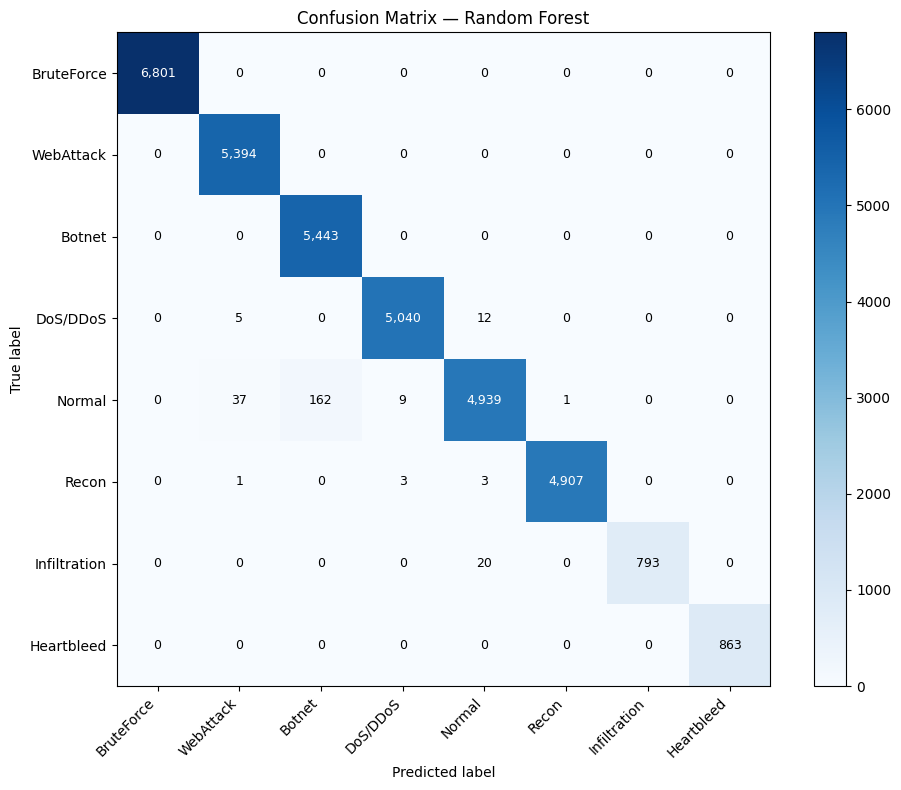

In [36]:
from pyspark.mllib.evaluation import MulticlassMetrics

predictions = cv_model.transform(test_df)

# Metrics
for metric in ["f1", "accuracy", "weightedPrecision", "weightedRecall"]:
    score = evaluator.evaluate(predictions, {evaluator.metricName: metric})
    print(f"{metric}: {score:.4f}")

# Confusion matrix
preds_and_labels = predictions.select("prediction", "label_index") \
    .rdd.map(lambda r: (float(r["prediction"]), float(r["label_index"])))

metrics_obj = MulticlassMetrics(preds_and_labels)
labels = sorted(predictions.select("label_index").distinct().rdd.map(lambda r: float(r[0])).collect())
cm = np.array([[metrics_obj.confusionMatrix().toArray()[int(i)][int(j)] for j in labels] for i in labels])

# FIX: column is "Label" (capital L), not "label"
label_map = {
    float(r["label_index"]): r["Label"]
    for r in predictions.select("Label", "label_index").distinct().collect()
}
label_names = [label_map[i] for i in labels]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(label_names)),
    yticks=np.arange(len(label_names)),
    xticklabels=label_names,
    yticklabels=label_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix — Random Forest"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

thresh = cm.max() / 2.0
for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, f"{int(cm[i, j]):,}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9)

plt.tight_layout()
plt.savefig("models/confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
print("Saved: models/confusion_matrix_rf.png")
plt.show()

## 5. Model 2 — XGBoost (Cross-Validated)

In [37]:
from xgboost.spark import SparkXGBClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

xgb = SparkXGBClassifier(
    features_col="features_selected",
    label_col="label_index",
    num_workers=1,
    device="cuda",
    tree_method="hist",
    seed=42,
    max_depth=5,
    n_estimators=50
)

xgb_grid = (
    ParamGridBuilder()
    .addGrid(xgb.max_depth, [5, 10])
    .addGrid(xgb.n_estimators, [50, 100])
    .build()
)

cv_xgb = CrossValidator(
    estimator=xgb,
    estimatorParamMaps=xgb_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

xgb_model = cv_xgb.fit(train_df)
xgb_model.write().overwrite().save("models/xgb_cv_model")
print("Saved: models/xgb_cv_model")
xgb_preds = xgb_model.transform(test_df)

2026-05-03 02:13:14,788 WARNING SparkXGBClassifier: _validate_gpu_params You have enabled GPU in spark local mode. Please make sure your local node has at least 1 GPUs
2026-05-03 02:13:14,937 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 1 workers with
	booster params: {'device': 'cuda', 'max_depth': 5, 'objective': 'multi:softprob', 'tree_method': 'hist', 'seed': 42, 'num_class': 8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'device': 'cuda', 'max_depth': 5, 'objective': 'multi:softprob', 'tree_method': 'hist', 'seed': 42, 'num_class': 8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-03 02:13:17,251 INFO XGBoost-PySpark: _train_booster Leveraging cuda:0 to train with QDM: off
[02:13:18] Task 0 got rank 0
[02:13:18] 

Saved: models/xgb_cv_model


In [38]:
for m in ["f1", "accuracy", "weightedPrecision", "weightedRecall"]:
    score = evaluator.evaluate(xgb_preds, {evaluator.metricName: m})
    print(f"{m}: {score:.4f}")

2026-05-03 02:14:52,445 INFO XGBoost-PySpark: predict_udf CUDF or Cupy is unavailable, fallback the inference on the CPUs
2026-05-03 02:14:53,370 INFO XGBoost-PySpark: predict_udf CUDF or Cupy is unavailable, fallback the inference on the CPUs


f1: 0.9981


2026-05-03 02:14:54,291 INFO XGBoost-PySpark: predict_udf CUDF or Cupy is unavailable, fallback the inference on the CPUs


accuracy: 0.9981


2026-05-03 02:14:55,269 INFO XGBoost-PySpark: predict_udf CUDF or Cupy is unavailable, fallback the inference on the CPUs


weightedPrecision: 0.9981


[Stage 420:=============================================>        (57 + 10) / 67]

weightedRecall: 0.9981


In [39]:
from pyspark.mllib.evaluation import MulticlassMetrics

def plot_confusion(predictions, title="Confusion Matrix", save_path=None):
    preds_and_labels = predictions.select("prediction", "label_index") \
        .rdd.map(lambda r: (float(r["prediction"]), float(r["label_index"])))

    metrics_obj = MulticlassMetrics(preds_and_labels)

    labels = sorted(
        predictions.select("label_index")
        .distinct()
        .rdd.map(lambda r: float(r[0]))
        .collect()
    )

    cm = metrics_obj.confusionMatrix().toArray()

    label_map = {
        float(r["label_index"]): r["Label"]
        for r in predictions.select("Label", "label_index").distinct().collect()
    }
    label_names = [label_map[i] for i in labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(label_names)),
        yticks=np.arange(len(label_names)),
        xticklabels=label_names,
        yticklabels=label_names,
        xlabel="Predicted label",
        ylabel="True label",
        title=title
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(
                j, i, f"{int(cm[i, j]):,}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9
            )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

/root/env/lib/python3.10/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
2026-05-03 02:14:56,201 INFO XGBoost-PySpark: predict_udf CUDF or Cupy is unavailable, fallback the inference on the CPUs
2026-05-03 02:14:56,715 INFO XGBoost-PySpark: predict_udf CUDF or Cupy is unavailable, fallback the inference on the CPUs
                                                                                

Saved: models/confusion_matrix_xgb.png


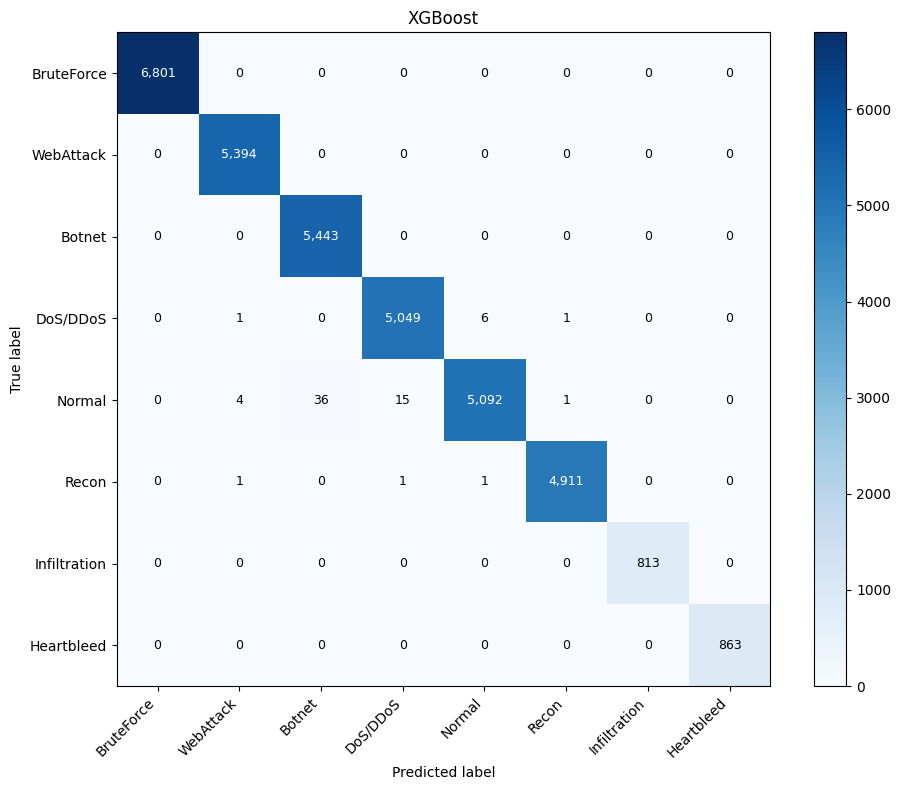

In [40]:
plot_confusion(xgb_preds, "XGBoost", save_path="models/confusion_matrix_xgb.png")

## 6. Model 3 — MLP Neural Network (Cross-Validated)

In [41]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.tuning import ParamGridBuilder

input_size = len(train_df.select("features_selected").first()[0])
num_classes = train_df.select("label_index").distinct().count()

mlp = MultilayerPerceptronClassifier(
    featuresCol="features_selected",
    labelCol="label_index",
    layers=[input_size, 64, 32, num_classes],
    seed=42,
    maxIter=100
)

mlp_grid = (
    ParamGridBuilder()
    .addGrid(mlp.stepSize, [0.01, 0.1])
    .addGrid(mlp.maxIter, [50, 100])
    .build()
)

cv_mlp = CrossValidator(
    estimator=mlp,
    estimatorParamMaps=mlp_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

mlp_model = cv_mlp.fit(train_df)
mlp_model.write().overwrite().save("models/mlp_cv_model")
print("Saved: models/mlp_cv_model")
mlp_preds = mlp_model.transform(test_df)

Saved: models/mlp_cv_model


In [42]:
for m in ["f1", "accuracy", "weightedPrecision", "weightedRecall"]:
    score = evaluator.evaluate(mlp_preds, {evaluator.metricName: m})
    print(f"{m}: {score:.4f}")

f1: 0.9732
accuracy: 0.9733
weightedPrecision: 0.9733
weightedRecall: 0.9733


/root/env/lib/python3.10/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Saved: models/confusion_matrix_mlp.png


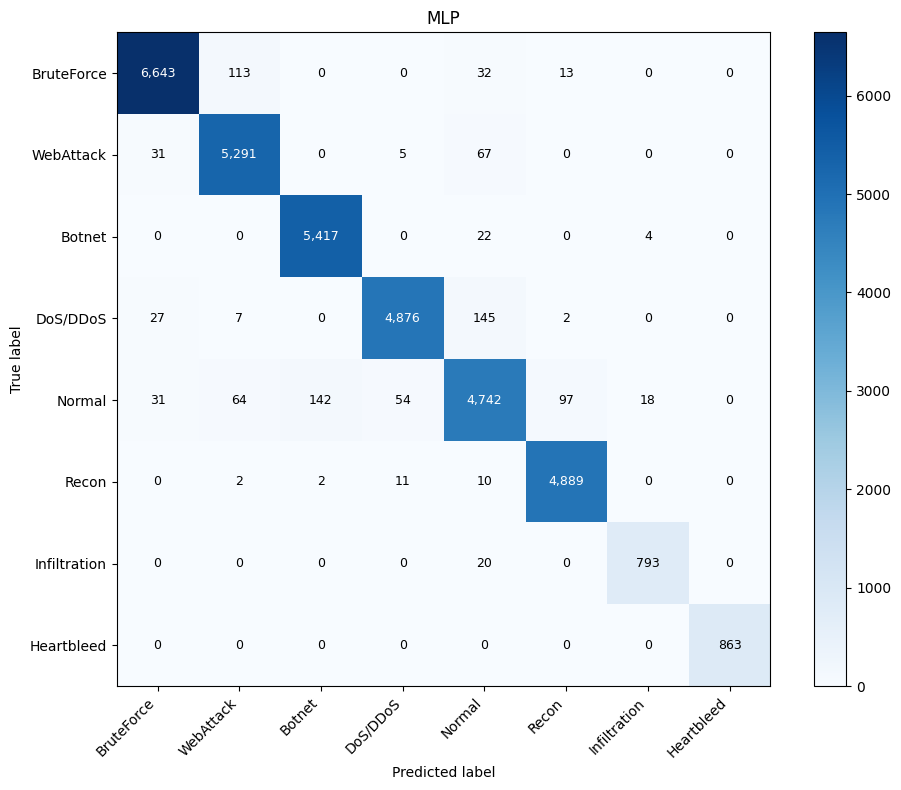

In [43]:
plot_confusion(mlp_preds, "MLP", save_path="models/confusion_matrix_mlp.png")

## 7. Model Comparison

In [44]:
import pandas as pd

models = {
    "Random Forest": predictions,
    "XGBoost": xgb_preds,
    "MLP": mlp_preds
}

metrics_list = ["f1", "accuracy", "weightedPrecision", "weightedRecall"]

results = []
for model_name, preds in models.items():
    row = {"model": model_name}
    for metric in metrics_list:
        score = evaluator.evaluate(preds, {evaluator.metricName: metric})
        row[metric] = score
    results.append(row)

df_results = pd.DataFrame(results)
print(df_results)

df_results.to_csv("models/model_comparison.csv", index=False)
with open("models/model_comparison.pkl", "wb") as f:
    pickle.dump(df_results, f)
print("Saved: models/model_comparison.csv, models/model_comparison.pkl")

/root/env/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [02:16:15] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/root/env/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [02:16:15] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device 

           model        f1  accuracy  weightedPrecision  weightedRecall
0  Random Forest  0.992625  0.992652           0.992762        0.992652
1        XGBoost  0.998052  0.998054           0.998060        0.998054
2            MLP  0.973218  0.973310           0.973279        0.973310
Saved: models/model_comparison.csv, models/model_comparison.pkl


Saved: models/model_comparison.png


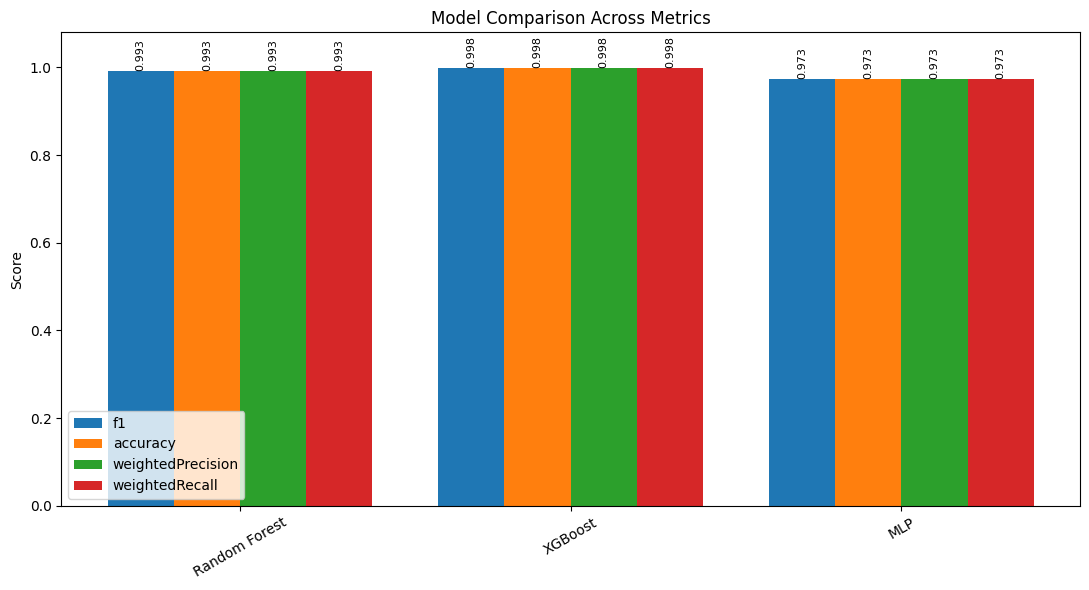

In [45]:
metrics = ["f1", "accuracy", "weightedPrecision", "weightedRecall"]

model_names = df_results["model"]
x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(11, 6))

for i, m in enumerate(metrics):
    bar = plt.bar(x + i * width, df_results[m], width, label=m)
    for rect in bar:
        height = rect.get_height()
        plt.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center", va="bottom",
            fontsize=8, rotation=90
        )

plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(x + width * 1.5, model_names, rotation=30)
plt.ylim(0, 1.08)
plt.legend()
plt.tight_layout()
plt.savefig("models/model_comparison.png", dpi=150, bbox_inches="tight")
print("Saved: models/model_comparison.png")
plt.show()

## 8. Stop Spark

In [24]:
spark.stop()